In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import gget
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.stats import pearsonr
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm


from scipy.spatial.distance import pdist, squareform
from collections import defaultdict

sc.settings.verbosity = 2

# Load in processed anndata

In [2]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 2.37 GB, difference +2.37 GB
CPU times: user 246 ms, sys: 1.6 s, total: 1.84 s
Wall time: 4.99 s


/home/jrcwycy/miniconda3/envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 15950 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'means', 'variance

# Dataset

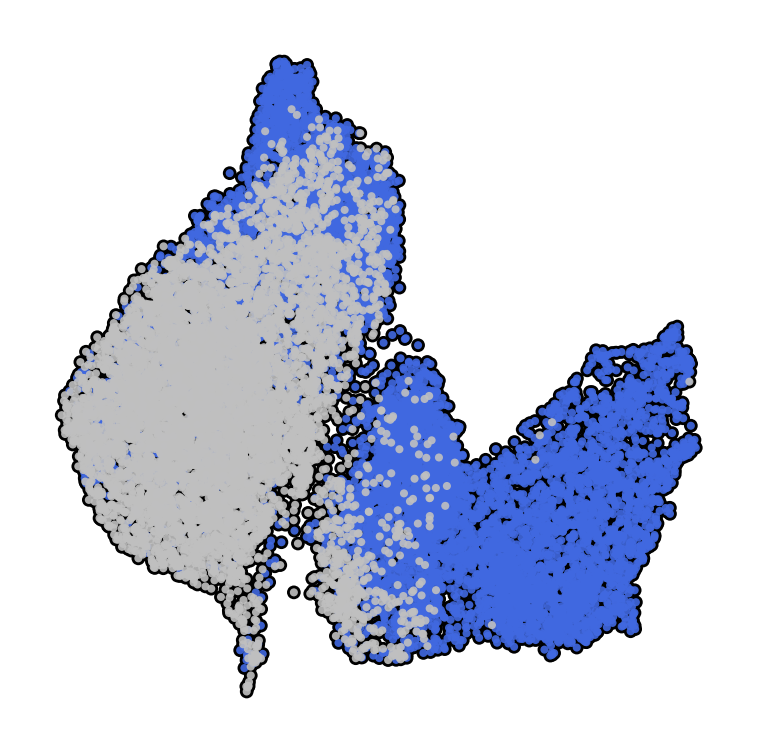

In [9]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 3, 3

dataset_colors = ["royalblue", "silver"]

sc.pl.umap(
    adata,
    color='dataset',
    size=15,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False, 
    alpha=0.9,
    title="",
    palette=dataset_colors,
    legend_loc='none',
)

# Conditions

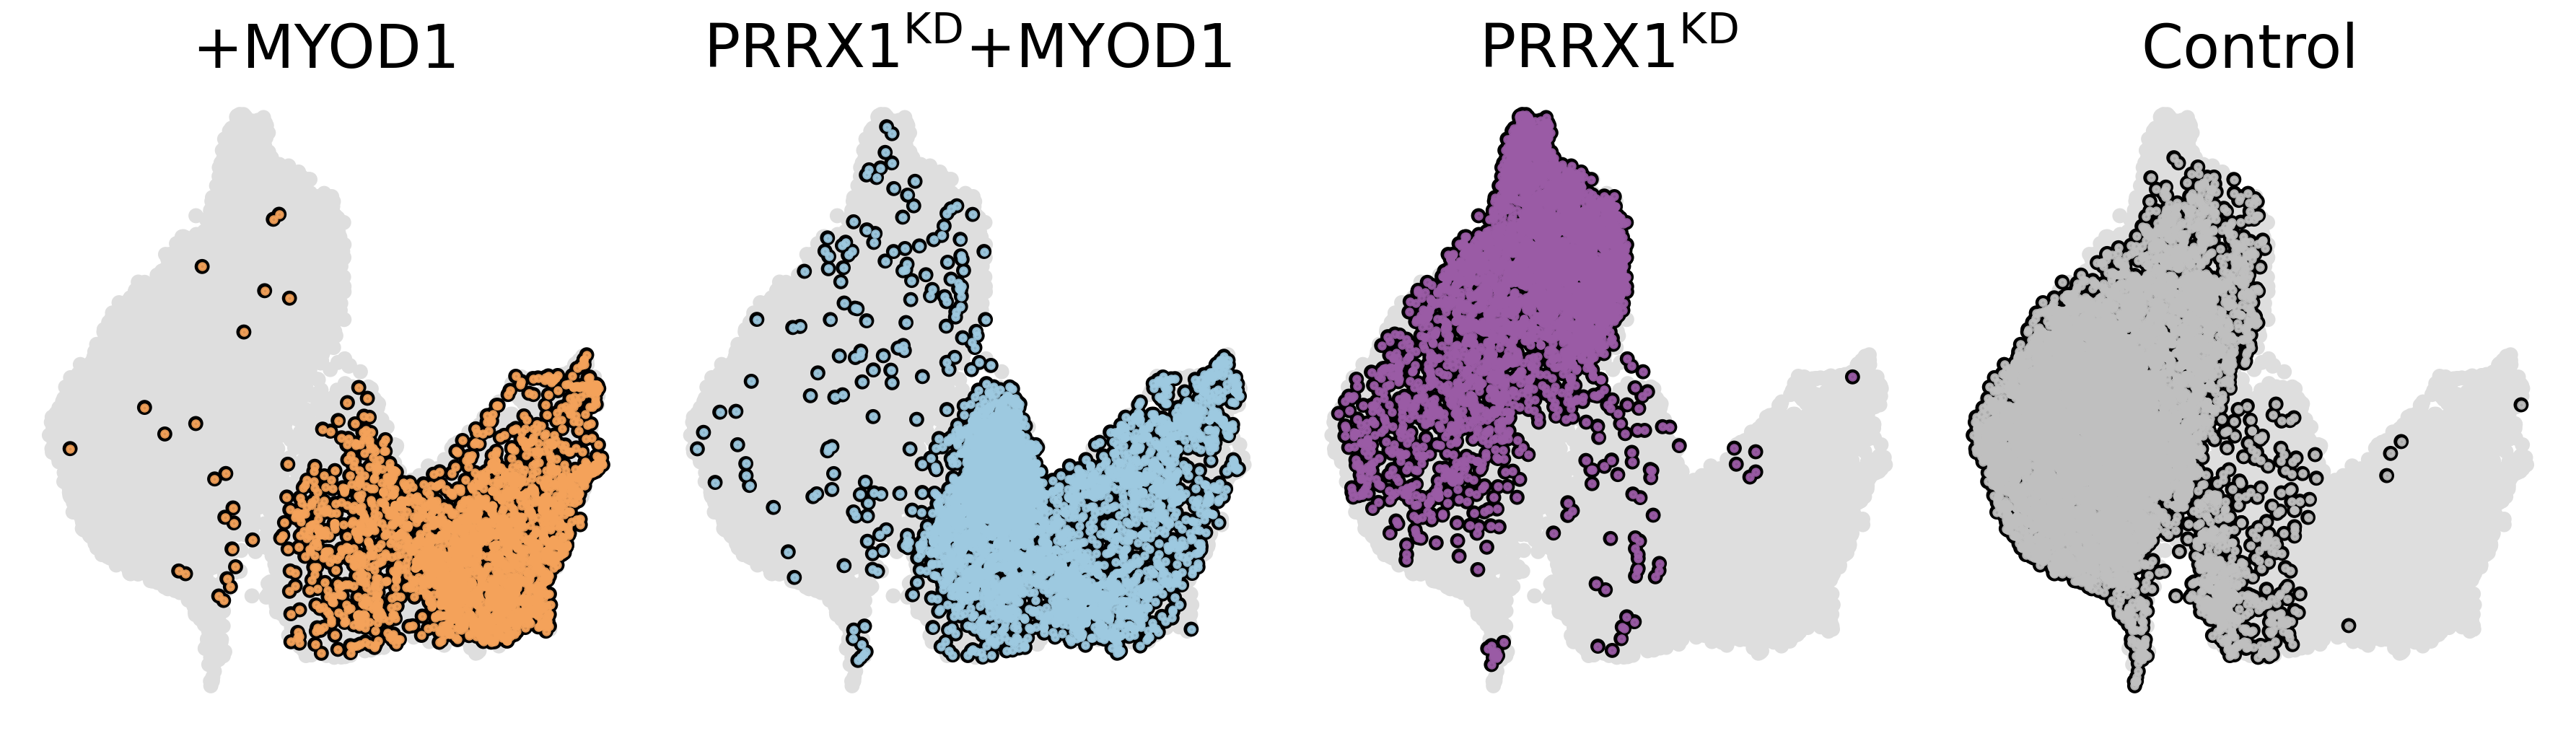

In [23]:
adata.obs['UMAP_1'] = adata.obsm['X_umap'][:, 0] 
adata.obs['UMAP_2'] = adata.obsm['X_umap'][:, 1]

predictions = ['mmMYOD1', 'siPRRX1/mmMYOD1', 'siPRRX1', 'Control']

titles = ['MYOD1$^+$', r'MYOD1$^+$PRRX1$^{\mathrm{KD}}$', 'PRRX1$^{KD}$', 'Control']
titles = ['+MYOD1', r'PRRX1$^{\mathrm{KD}}$+MYOD1', r'PRRX1$^{\mathrm{KD}}$', 'Control']

ncols = 4
nrows = int(np.ceil(len(predictions) / ncols))

plt.rcParams['figure.figsize'] = 12, 3.5
plt.rcParams['figure.dpi'] = 300

fig, axes = plt.subplots(nrows=nrows, ncols=ncols)
axes = axes.flatten()

colors = ["#F5A35B", "#9ECAE1", "#9B5CA6", "silver"]

for i, pred in enumerate(predictions):
    ax = axes[i]

    pred_indices = adata.obs['pooled_condition'] == pred

    # Plot background UMAP in grey
    sns.scatterplot(
        data=adata.obs,
        x='UMAP_1',
        y='UMAP_2',
        ec='none',
        s=25,
        color='#DEDEDE',
        ax=ax,
    )

    # Plot only the cells with the current prediction
    ax.scatter(
        adata.obs.loc[pred_indices, 'UMAP_1'],
        adata.obs.loc[pred_indices, 'UMAP_2'],
        c='black',
        s=25,
        alpha=1,
        edgecolors='none',
        linewidths=0,
    )

    
    ax.scatter(
        adata.obs.loc[pred_indices, 'UMAP_1'],
        adata.obs.loc[pred_indices, 'UMAP_2'],
        c=colors[i],
        s=4,
        label=pred,
        alpha=0.9,
    )
    
    ax.set_title(titles[i], fontsize=20)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis(False)

# Remove any extra empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Cell cycle phase

In [24]:
phase_group_map = {
    "G1": "G1/S",
    "S": "G1/S",
    "G2M": "G2/M"
}

adata.obs["condition_by_phase_group"] = (
    adata.obs["pooled_condition"].astype(str) + "_" +
    adata.obs["phase"].map(phase_group_map)
)

# Make categorical and optionally order
conditions = ["Control", "mmMYOD1", "siPRRX1", "siPRRX1/mmMYOD1"]
phase_groups = ["G1/S", "G2/M"]
ordered_categories = [f"{cond}_{ph}" for ph in phase_groups for cond in conditions]

adata.obs["condition_by_phase_group"] = pd.Categorical(
    adata.obs["condition_by_phase_group"],
    categories=ordered_categories,
    ordered=True
)

adata.obs["condition_by_phase_group"].value_counts(sort=False)

condition_by_phase_group
Control_G1/S            3770
mmMYOD1_G1/S            1733
siPRRX1_G1/S            1936
siPRRX1/mmMYOD1_G1/S    2415
Control_G2/M            3190
mmMYOD1_G2/M             376
siPRRX1_G2/M            1494
siPRRX1/mmMYOD1_G2/M    1036
Name: count, dtype: int64

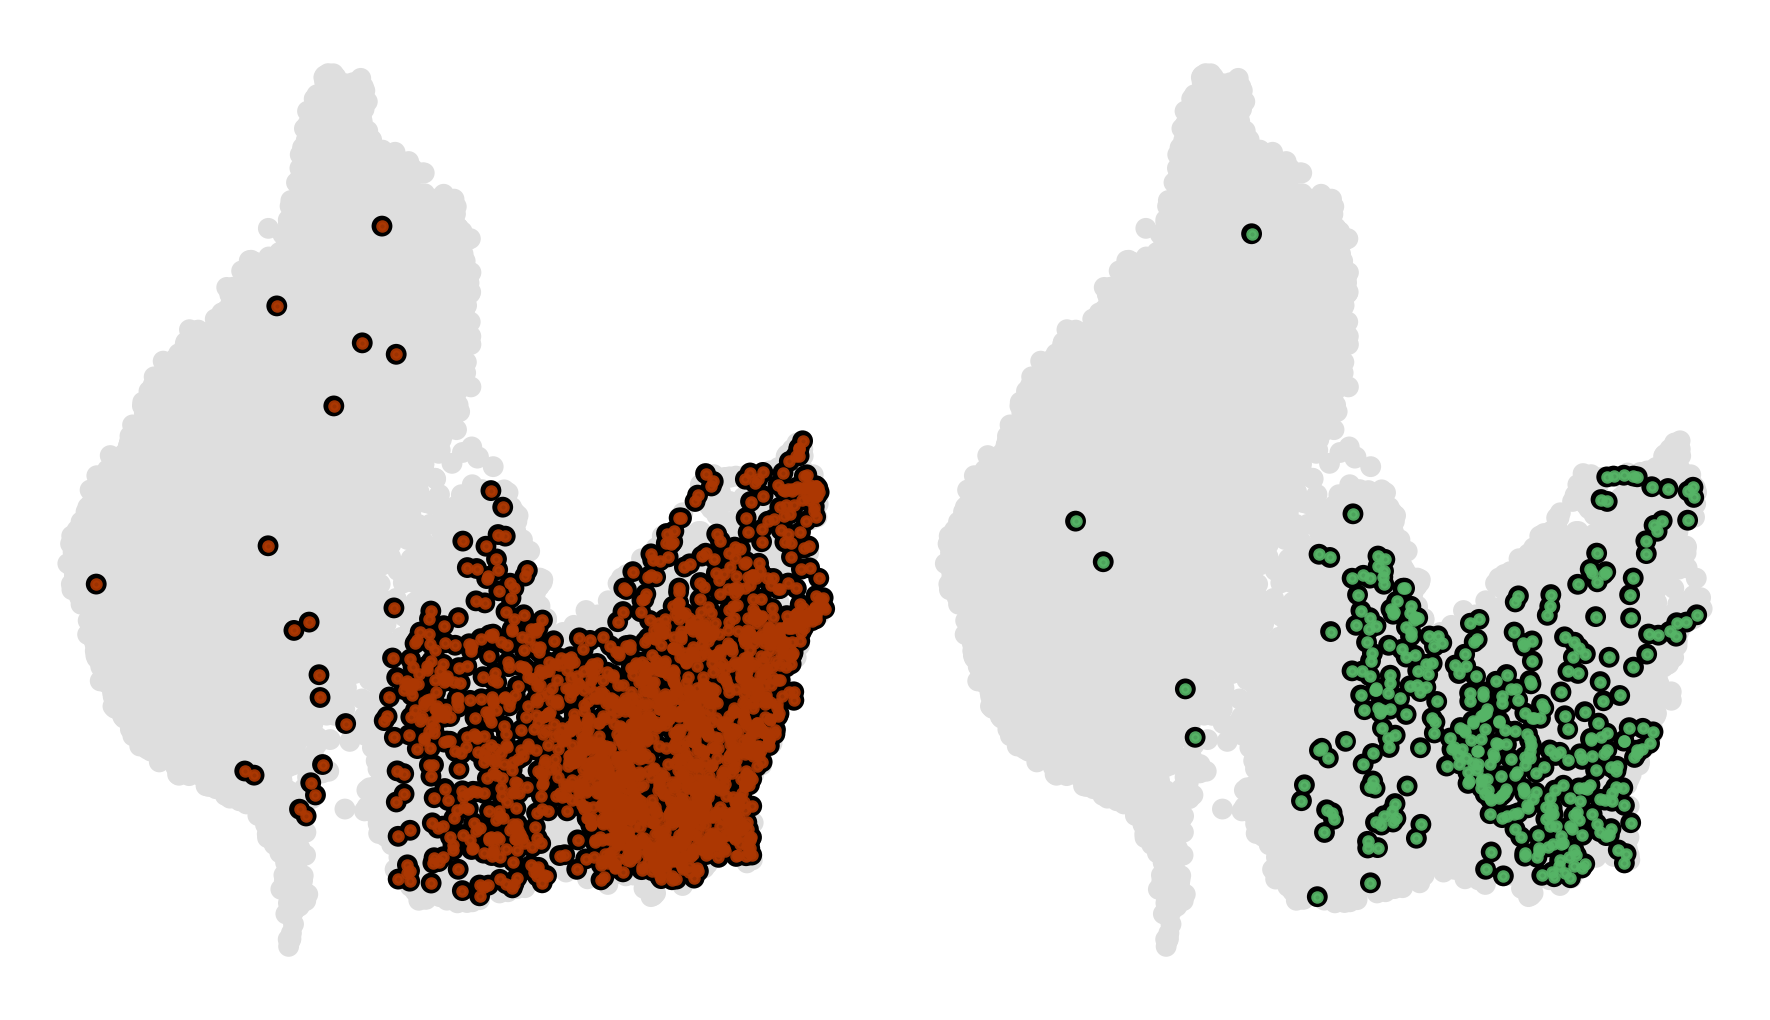

In [26]:
# adata.obs['UMAP_1'] = adata.obsm['X_umap'][:, 0] 
# adata.obs['UMAP_2'] = adata.obsm['X_umap'][:, 1]

# predictions = ['mmMYOD1', 'siPRRX1/mmMYOD1', 'siPRRX1', 'Control']

# titles = ['MYOD1$^+$', r'MYOD1$^+$PRRX1$^{\mathrm{KD}}$', 'PRRX1$^{KD}$', 'Control']
# titles = ['+MYOD1', r'PRRX1$^{\mathrm{KD}}$+MYOD1', r'PRRX1$^{\mathrm{KD}}$', 'Control']

# ncols = 4
# nrows = int(np.ceil(len(predictions) / ncols))

plt.rcParams['figure.figsize'] = 6, 3.5
plt.rcParams['figure.dpi'] = 300

fig, axes = plt.subplots(nrows=1, ncols=2)
axes = axes.flatten()

# colors = ["#F5A35B", "#9ECAE1", "#9B5CA6", "silver"]

colors = ['#ad3803', '#56b567']

group = 'mmMYOD1'

group_phases = [f'{group}_G1/S', f'{group}_G2/M']

for i, phase in enumerate(group_phases):
    ax = axes[i]

    phase_indices = adata.obs['condition_by_phase_group'] == phase

    # Plot background UMAP in grey
    sns.scatterplot(
        data=adata.obs,
        x='UMAP_1',
        y='UMAP_2',
        ec='none',
        s=25,
        color='#DEDEDE',
        ax=ax,
    )

    # Plot only the cells with the current prediction
    ax.scatter(
        adata.obs.loc[phase_indices, 'UMAP_1'],
        adata.obs.loc[phase_indices, 'UMAP_2'],
        c='black',
        s=25,
        alpha=1,
        edgecolors='none',
        linewidths=0,
    )

    
    ax.scatter(
        adata.obs.loc[phase_indices, 'UMAP_1'],
        adata.obs.loc[phase_indices, 'UMAP_2'],
        c=colors[i],
        s=4,
        label=phase,
        alpha=0.9,
    )
    
    ax.set_title("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis(False)

# Remove any extra empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [27]:
adata.obs["condition_by_phase"] = (
    adata.obs["pooled_condition"].astype(str) + "_" + adata.obs["phase"].astype(str)
)

conditions = ["Control", "mmMYOD1", "siPRRX1", "siPRRX1/mmMYOD1"]
phases = ["G1", "S", "G2M"]

ordered_categories = [f"{cond}_{ph}" for ph in phases for cond in conditions]

# Apply categorical with ordering
adata.obs["condition_by_phase"] = pd.Categorical(
    adata.obs["condition_by_phase"],
    categories=ordered_categories,
    ordered=True
)

# Now value_counts will respect this order if you use sort=False
adata.obs["condition_by_phase"].value_counts(sort=False)

condition_by_phase
Control_G1             3551
mmMYOD1_G1             1422
siPRRX1_G1             1409
siPRRX1/mmMYOD1_G1     1803
Control_S               219
mmMYOD1_S               311
siPRRX1_S               527
siPRRX1/mmMYOD1_S       612
Control_G2M            3190
mmMYOD1_G2M             376
siPRRX1_G2M            1494
siPRRX1/mmMYOD1_G2M    1036
Name: count, dtype: int64

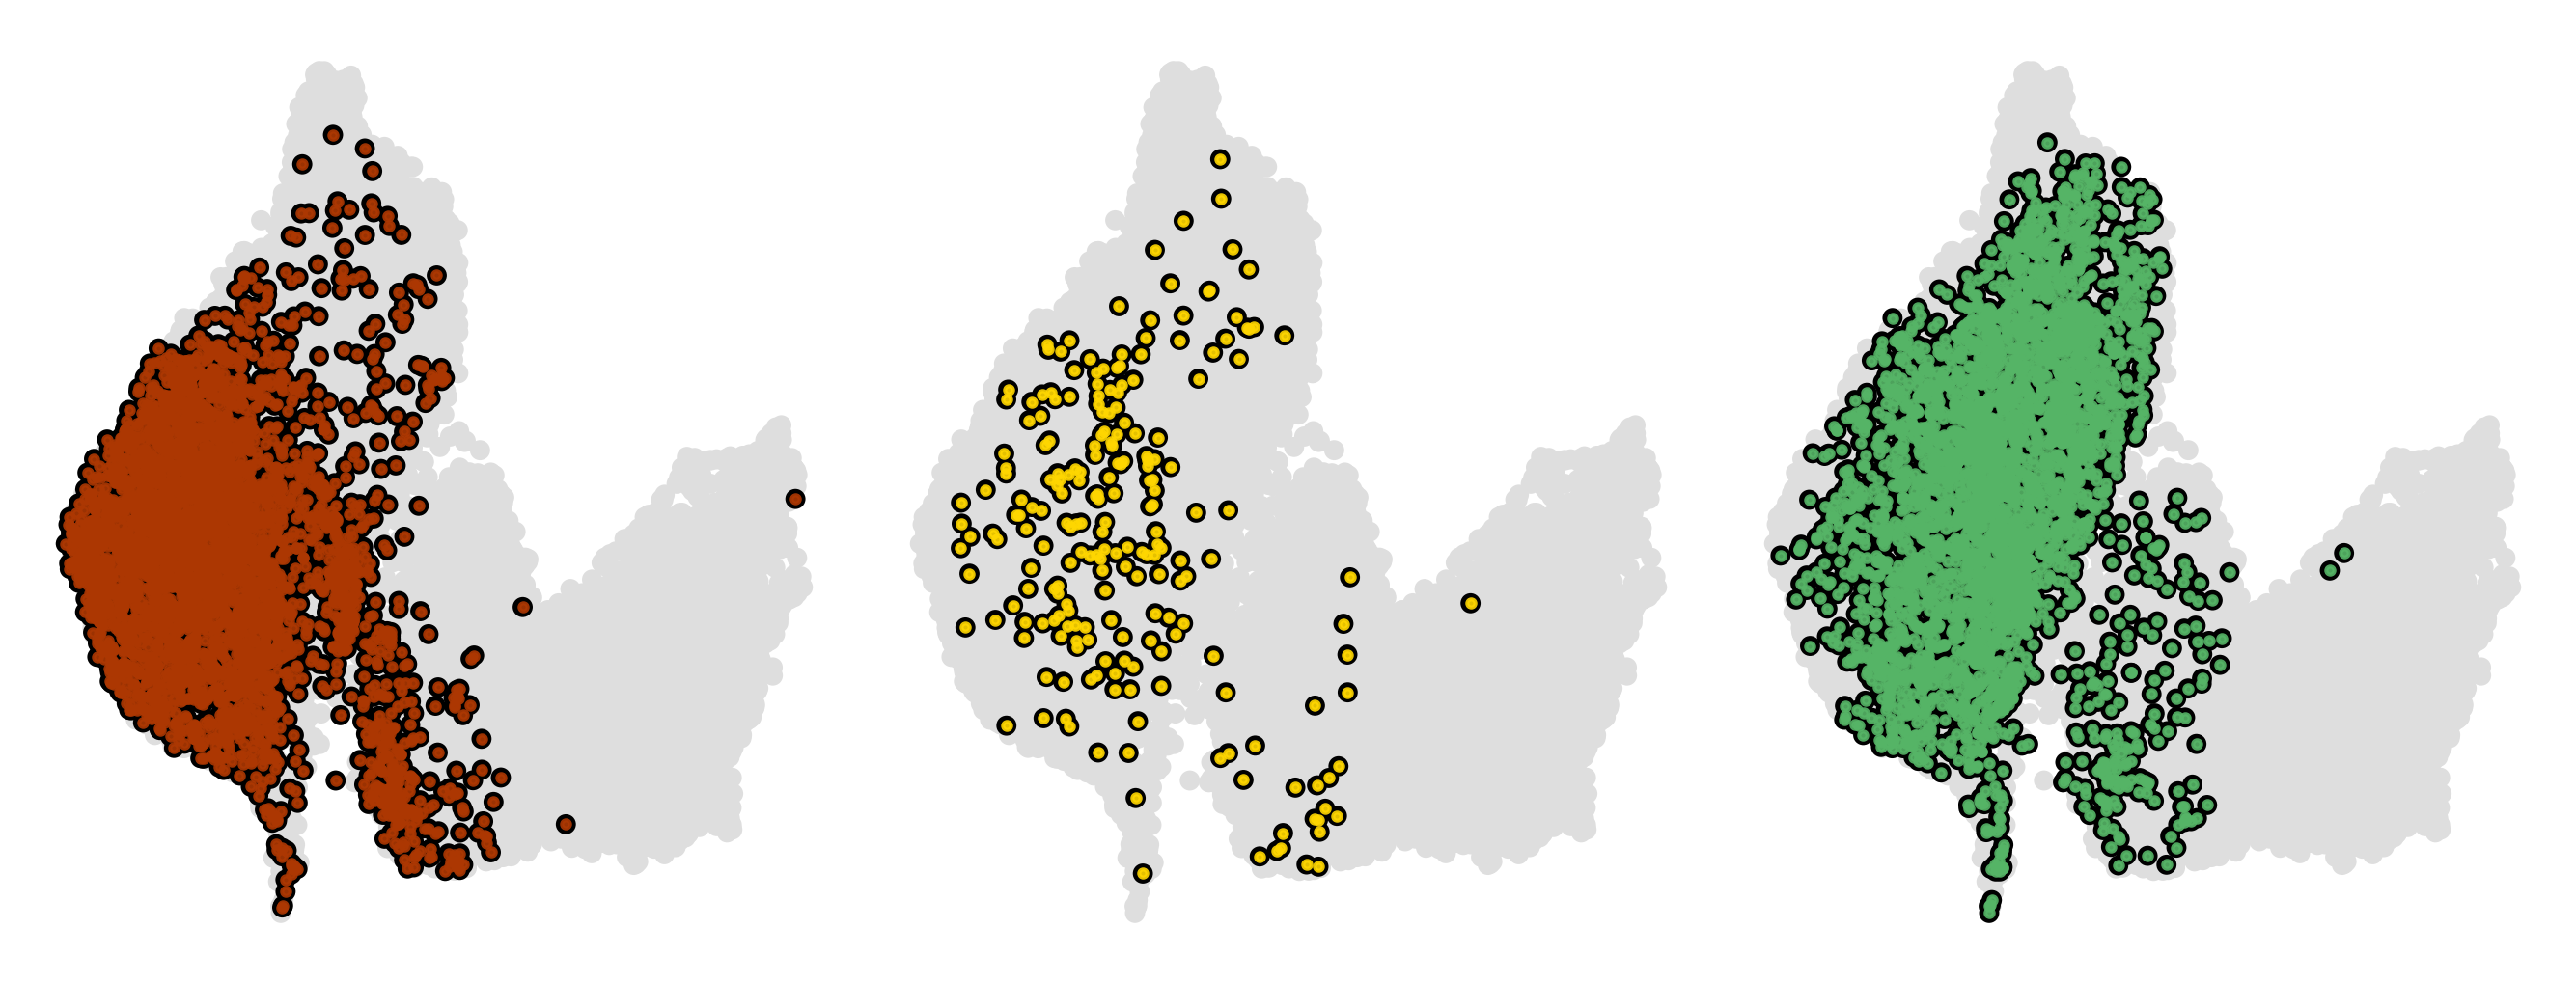

In [31]:
plt.rcParams['figure.figsize'] = 9, 3.5
plt.rcParams['figure.dpi'] = 300

fig, axes = plt.subplots(nrows=1, ncols=3)
axes = axes.flatten()


colors = ['#ad3803', 'gold', '#56b567']

group = 'Control'

group_phases = [f'{group}_G1', f'{group}_S', f'{group}_G2M']

for i, phase in enumerate(group_phases):
    ax = axes[i]

    phase_indices = adata.obs['condition_by_phase'] == phase

    # Plot background UMAP in grey
    sns.scatterplot(
        data=adata.obs,
        x='UMAP_1',
        y='UMAP_2',
        ec='none',
        s=25,
        color='#DEDEDE',
        ax=ax,
    )

    # Plot only the cells with the current prediction
    ax.scatter(
        adata.obs.loc[phase_indices, 'UMAP_1'],
        adata.obs.loc[phase_indices, 'UMAP_2'],
        c='black',
        s=25,
        alpha=1,
        edgecolors='none',
        linewidths=0,
    )

    
    ax.scatter(
        adata.obs.loc[phase_indices, 'UMAP_1'],
        adata.obs.loc[phase_indices, 'UMAP_2'],
        c=colors[i],
        s=4,
        label=phase,
        alpha=0.9,
    )
    
    ax.set_title("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis(False)

# Remove any extra empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()